### **Project On Loan Prediction**

### **1.Load Library**

In [192]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_score,GridSearchCV,cross_validate,RandomizedSearchCV
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# RandomForest Classifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier,ExtraTreesClassifier,HistGradientBoostingClassifier
# Support Vector Classifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
# XGB Classifier
from xgboost import XGBClassifier
# standard Scaler

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
# Pipeline
from sklearn.pipeline import Pipeline
# imbalance 
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,average_precision_score,confusion_matrix

pd.set_option("display.max_columns",None)

### **2.Load Dataset**

In [2]:
df = pd.read_csv("loan_dataset.csv")

In [3]:
print("Shape:",df.shape)
print("Size:",df.size)

Shape: (614, 13)
Size: 7982


In [4]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.columns.to_list()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

### **3.Exploratory data analysis (EDA)**

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
df.isnull().sum()

loan_id               0
gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64

In [10]:
df["loan_status"].value_counts()

loan_status
Y    422
N    192
Name: count, dtype: int64

In [11]:
df["loan_status"].value_counts(normalize = True)

loan_status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

In [12]:
df["loan_status"] = df["loan_status"].map({"Y":1,"N":0})

In [13]:
df["gender"] = df["gender"].map({"Male":1,"Female":0})

In [14]:
df["married"] = df["married"].map({"No":0,"Yes":1})

In [15]:
df["self_employed"] = df["self_employed"].map({"No":0,"Yes":1})

In [16]:
df["education"] = df["education"].map({"Graduate":0,"Not Graduate":1})

In [17]:
df["education"].value_counts()

education
0    480
1    134
Name: count, dtype: int64

In [18]:
df["dependents"] = df["dependents"].replace("3+",3).astype("float")

In [19]:
df["self_employed"]

0      0.0
1      0.0
2      1.0
3      0.0
4      0.0
      ... 
609    0.0
610    0.0
611    0.0
612    0.0
613    1.0
Name: self_employed, Length: 614, dtype: float64

In [20]:
df["married"]

0      0.0
1      1.0
2      1.0
3      1.0
4      0.0
      ... 
609    0.0
610    1.0
611    1.0
612    1.0
613    0.0
Name: married, Length: 614, dtype: float64

In [21]:
df["loan_status"]

0      1
1      0
2      1
3      1
4      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: loan_status, Length: 614, dtype: int64

In [22]:
df["gender"].dtype

dtype('float64')

In [23]:
columns = df.columns.to_list()

In [24]:
df.nunique().sort_values(ascending = True)

gender                 2
married                2
self_employed          2
education              2
loan_status            2
credit_history         2
property_area          3
dependents             4
loan_amount_term      10
loanamount           203
coapplicantincome    287
applicantincome      505
loan_id              614
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df[df.duplicated()]

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status


In [27]:
df["gender"].value_counts()

gender
1.0    489
0.0    112
Name: count, dtype: int64

In [28]:
df["loan_status"].dtype

dtype('int64')

In [29]:
df["gender"].isna().sum()

np.int64(13)

In [30]:
df["gender"].isna()

0      False
1      False
2      False
3      False
4      False
       ...  
609    False
610    False
611    False
612    False
613    False
Name: gender, Length: 614, dtype: bool

In [31]:
# quasi constant value remains to get
for col in columns:
    print(df[col].value_counts())

loan_id
LP001002    1
LP001003    1
LP001005    1
LP001006    1
LP001008    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    1
Name: count, Length: 614, dtype: int64
gender
1.0    489
0.0    112
Name: count, dtype: int64
married
1.0    398
0.0    213
Name: count, dtype: int64
dependents
0.0    345
1.0    102
2.0    101
3.0     51
Name: count, dtype: int64
education
0    480
1    134
Name: count, dtype: int64
self_employed
0.0    500
1.0     82
Name: count, dtype: int64
applicantincome
2500    9
4583    6
6000    6
2600    6
3750    5
       ..
3232    1
2900    1
4106    1
8072    1
7583    1
Name: count, Length: 505, dtype: int64
coapplicantincome
0.0       273
2083.0      5
1666.0      5
2500.0      5
5625.0      3
         ... 
2792.0      1
4301.0      1
3800.0      1
1411.0      1
240.0       1
Name: count, Length: 287, dtype: int64
loanamount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
         ..
292.0     1
142.0     1
350.0   

**3.1 Plotting the graph**

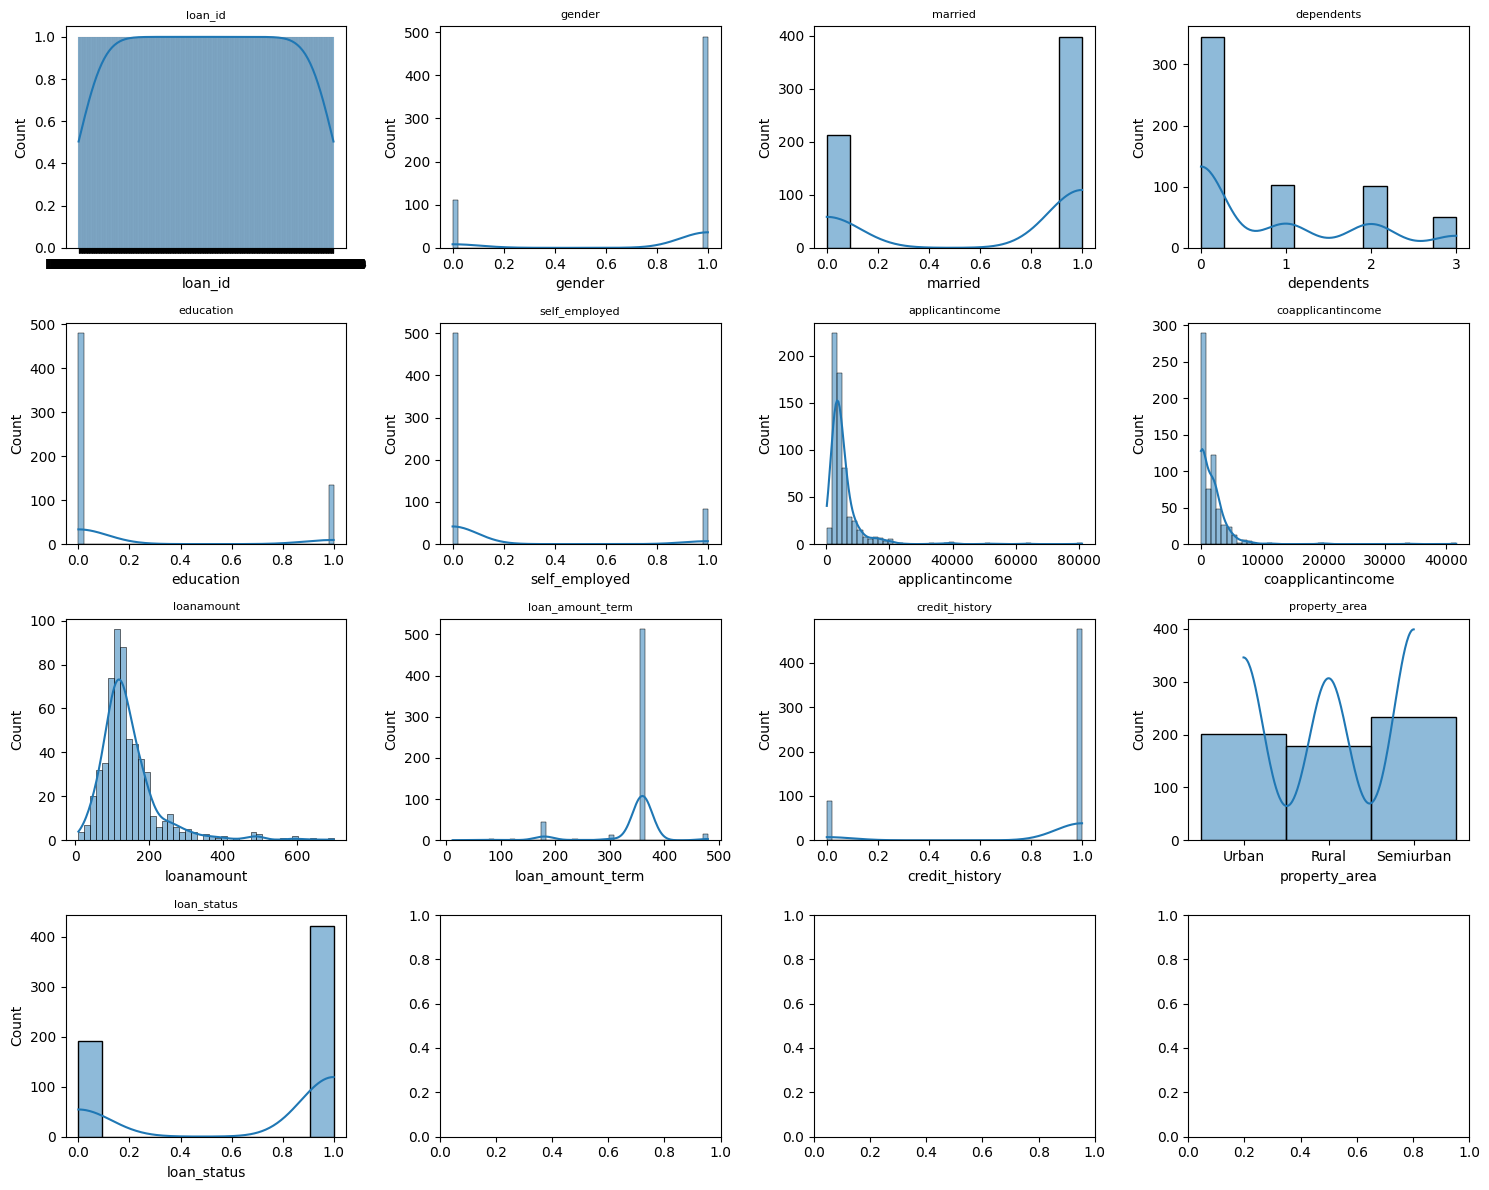

In [32]:
# HistPlot 
fig,axes = plt.subplots(4,4,figsize = (15,12))
axes = axes.flatten()

for i,col in enumerate(df.columns):
    sns.histplot(df[col],kde = True,ax = axes[i])
    axes[i].set_title(col,fontsize = 8)
plt.tight_layout()
plt.show()

In [33]:
df.groupby("loan_status")[["applicantincome", "loanamount"]].mean()

,applicantincome,loanamount
loan_status,,
0,5446.078125,151.220994
1,5384.068720,144.294404


In [34]:
# constant & quasi-constant columns - can identify the columns that has almost similar values throughout
n_rows = len(df)
nunique = df.nunique()

constant_cols = nunique[nunique == 1].index.tolist()
print("Constant columns:", constant_cols)

# Quasi constant: top value more than 95 percent
quasi_constant_cols = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq > 0.95 and col not in constant_cols:
        quasi_constant_cols.append(col)

print("Quasi constant columns (top value more than 95 percent):", quasi_constant_cols)

Constant columns: []
Quasi constant columns (top value more than 95 percent): []


#BoxPlot

fig,axes = plt.subplots(4,4,figsize = (15,12))
axes = axes.flatten()

for i,col in enumerate(df.columns):
    sns.boxplot(df[col],ax = axes[i])
    axes[i].set_title(col,fontsize = 8)
plt.tight_layout()
plt.show()

### **4.Preprocessing**

-- 1.Remove loanid first
-- 2. Split our data
-- 3.handle missing values
-- 4.handle the outliers 
-- 5.convert the categorical data into numerical data
-- 6.handle the imbalance data with the help of smote function
-- 7.Scaling the values.

**4.1 Remove the Loan_id first**

In [35]:
df = df.drop(columns = ["loan_id"])

In [36]:
df.shape

(614, 12)

In [37]:
df.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,1.0,0.0,0.0,0,0.0,5849,0.0,NaN,360.0,1.0,Urban,1
1,1.0,1.0,1.0,0,0.0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,1.0,1.0,0.0,0,1.0,3000,0.0,66.0,360.0,1.0,Urban,1
3,1.0,1.0,0.0,1,0.0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,1.0,0.0,0.0,0,0.0,6000,0.0,141.0,360.0,1.0,Urban,1


In [38]:
columns

['loan_id',
 'gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history',
 'property_area',
 'loan_status']

In [39]:
target = "loan_status"

In [40]:
X = df.drop(columns = [target])
y = df[target]

In [41]:
print("Shape of X:",X.shape)
print("Shape of y:",y.shape)

Shape of X: (614, 11)
Shape of y: (614,)


**4.2 Split the data**

In [42]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    random_state = 42,
    test_size = 0.2,
    stratify = y
)

In [43]:
print("Shape of X :",X.shape)
print("Shape of X_train :",X_train.shape)
print("Shape of X_test :",X_test.shape)
print("Shape of y_train :",y_train.shape)
print("Shape of y_test :",y_test.shape)

Shape of X : (614, 11)
Shape of X_train : (491, 11)
Shape of X_test : (123, 11)
Shape of y_train : (491,)
Shape of y_test : (123,)


In [44]:
X_train.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,1.0,0.0,0.0,0,0.0,3254,0.0,50.0,360.0,1.0,Urban
239,1.0,1.0,1.0,0,0.0,3315,0.0,96.0,360.0,1.0,Semiurban
448,1.0,1.0,2.0,0,0.0,3340,1710.0,150.0,360.0,0.0,Rural
471,1.0,1.0,1.0,1,0.0,2653,1500.0,113.0,180.0,0.0,Rural
273,1.0,1.0,0.0,0,0.0,2620,2223.0,150.0,360.0,1.0,Semiurban


In [45]:
X_test.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
150,1.0,0.0,0.0,0,0.0,6277,0.0,118.0,360.0,0.0,Rural
559,0.0,1.0,0.0,0,0.0,4180,2306.0,182.0,360.0,1.0,Semiurban
598,1.0,1.0,0.0,0,1.0,9963,0.0,180.0,360.0,1.0,Rural
235,1.0,1.0,1.0,0,0.0,5500,1260.0,170.0,360.0,1.0,Rural
145,0.0,1.0,0.0,0,0.0,2330,4486.0,100.0,360.0,1.0,Semiurban


In [46]:
y_train.head()

154    1
239    1
448    0
471    0
273    1
Name: loan_status, dtype: int64

In [47]:
y_test.head()

150    0
559    1
598    1
235    1
145    1
Name: loan_status, dtype: int64

**4.3 Handle the missing values**

In [48]:
num_cols = X_train.select_dtypes(include = [np.number]).columns.to_list()

In [49]:
cat_cols = [x for x in X_train.columns if x not in num_cols]

In [50]:
print("numerical columns:",num_cols)
print("-"*50)
print("categorical columns :",cat_cols)

numerical columns: ['gender', 'married', 'dependents', 'education', 'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount', 'loan_amount_term', 'credit_history']
--------------------------------------------------
categorical columns : ['property_area']


In [51]:
df[num_cols].dtypes

gender               float64
married              float64
dependents           float64
education              int64
self_employed        float64
applicantincome        int64
coapplicantincome    float64
loanamount           float64
loan_amount_term     float64
credit_history       float64
dtype: object

In [52]:
df[cat_cols].dtypes

property_area    str
dtype: object

In [53]:
X_train

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area
154,1.0,0.0,0.0,0,0.0,3254,0.0,50.0,360.0,1.0,Urban
239,1.0,1.0,1.0,0,0.0,3315,0.0,96.0,360.0,1.0,Semiurban
448,1.0,1.0,2.0,0,0.0,3340,1710.0,150.0,360.0,0.0,Rural
471,1.0,1.0,1.0,1,0.0,2653,1500.0,113.0,180.0,0.0,Rural
273,1.0,1.0,0.0,0,0.0,2620,2223.0,150.0,360.0,1.0,Semiurban
...,...,...,...,...,...,...,...,...,...,...,...
222,1.0,0.0,0.0,0,0.0,2971,2791.0,144.0,360.0,1.0,Semiurban
349,1.0,1.0,0.0,0,0.0,2625,6250.0,187.0,360.0,1.0,Rural
26,1.0,1.0,0.0,0,0.0,2799,2253.0,122.0,360.0,1.0,Semiurban
96,0.0,1.0,0.0,0,0.0,2484,2302.0,137.0,360.0,1.0,Semiurban


In [54]:
X_train[num_cols].isna().sum()

gender               11
married               3
dependents            8
education             0
self_employed        27
applicantincome       0
coapplicantincome     0
loanamount           20
loan_amount_term     12
credit_history       43
dtype: int64

**4.3.1 Handle the numerical missing columns**

In [55]:
handle_num = {}
for col in num_cols:
    mean = X_train[col].mean()
    handle_num[col] = mean
    X_train[col] = X_train[col].fillna(mean)
    X_test[col] = X_test[col].fillna(mean)

In [56]:
handle_num

{'gender': np.float64(0.81875),
 'married': np.float64(0.6536885245901639),
 'dependents': np.float64(0.7619047619047619),
 'education': np.float64(0.22606924643584522),
 'self_employed': np.float64(0.14224137931034483),
 'applicantincome': np.float64(5529.997963340123),
 'coapplicantincome': np.float64(1569.5372708509165),
 'loanamount': np.float64(147.3099787685775),
 'loan_amount_term': np.float64(341.28601252609604),
 'credit_history': np.float64(0.8504464285714286)}

In [57]:
X_train[num_cols].isna().sum()

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
dtype: int64

In [58]:
X_train.isna().sum()

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64

In [59]:
X_train[cat_cols]

,property_area
154,Urban
239,Semiurban
448,Rural
471,Rural
273,Semiurban
...,...
222,Semiurban
349,Rural
26,Semiurban
96,Semiurban


In [60]:
for num in cat_cols:
    print(X_train[num].value_counts())
    print("-"*50)

property_area
Semiurban    184
Urban        162
Rural        145
Name: count, dtype: int64
--------------------------------------------------


In [61]:
for X in X_train:
    print(df[X].value_counts())

gender
1.0    489
0.0    112
Name: count, dtype: int64
married
1.0    398
0.0    213
Name: count, dtype: int64
dependents
0.0    345
1.0    102
2.0    101
3.0     51
Name: count, dtype: int64
education
0    480
1    134
Name: count, dtype: int64
self_employed
0.0    500
1.0     82
Name: count, dtype: int64
applicantincome
2500    9
4583    6
6000    6
2600    6
3750    5
       ..
3232    1
2900    1
4106    1
8072    1
7583    1
Name: count, Length: 505, dtype: int64
coapplicantincome
0.0       273
2083.0      5
1666.0      5
2500.0      5
5625.0      3
         ... 
2792.0      1
4301.0      1
3800.0      1
1411.0      1
240.0       1
Name: count, Length: 287, dtype: int64
loanamount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0     1
Name: count, Length: 203, dtype: int64
loan_amount_term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2


In [62]:
X_train.isna().sum()

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64

In [63]:
df[X_train.columns].isna().sum()

gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
dtype: int64

In [64]:
print("DF missing:\n", df.isna().sum())
print("Train missing:\n", X_train.isna().sum())
print("Test missing:\n", X_test.isna().sum())

DF missing:
 gender               13
married               3
dependents           15
education             0
self_employed        32
applicantincome       0
coapplicantincome     0
loanamount           22
loan_amount_term     14
credit_history       50
property_area         0
loan_status           0
dtype: int64
Train missing:
 gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64
Test missing:
 gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64


**4.3.2 Handle the missing values in categorical columns**

In [65]:
handle_cat = {}
for cat in cat_cols:
    mode = X_train[cat].mode().iloc[0]
    handle_cat[cat] = mode
    X_train[cat] = X_train[cat].fillna(mode)
    X_test[cat] = X_test[cat].fillna(mode)

In [66]:
handle_cat

{'property_area': 'Semiurban'}

In [67]:
X_train[cat_cols].isna().sum()

property_area    0
dtype: int64

In [68]:
X_train.isna().sum()

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64

In [69]:
X_test.isna().sum()

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64

In [70]:
y_train.isna().sum()

np.int64(0)

In [71]:
y_test.isna().sum()

np.int64(0)

**4.4handle the outliers**


In [72]:
X_train_out = X_train.copy()
X_test_out = X_test.copy()

In [73]:
num_cols

['gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history']

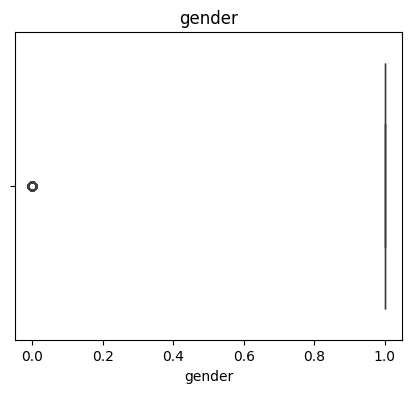

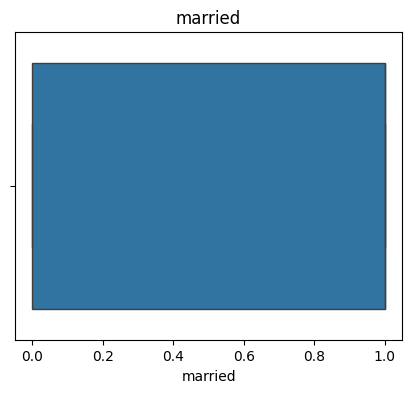

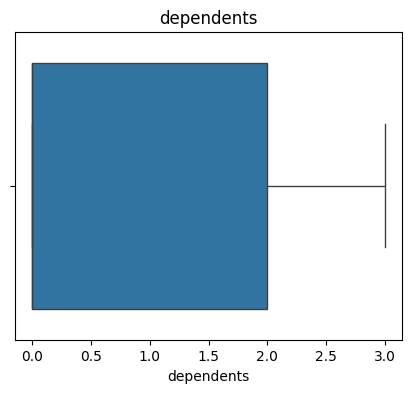

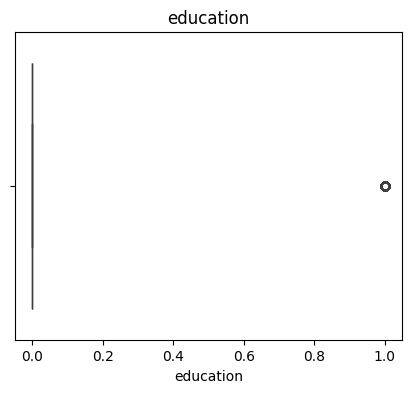

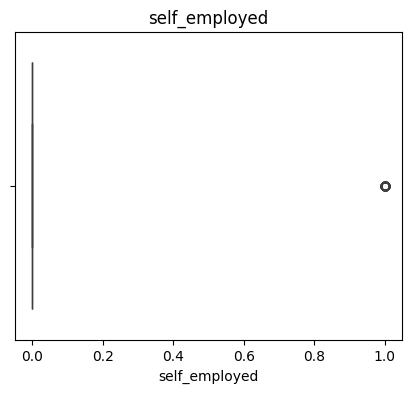

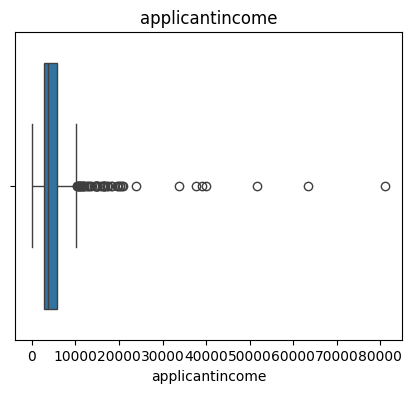

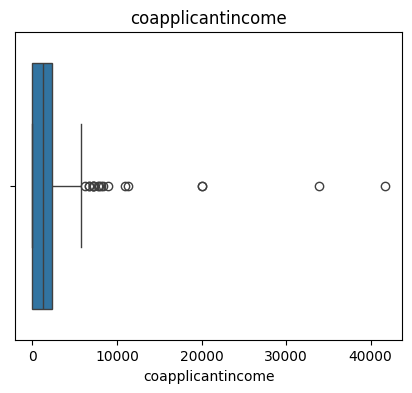

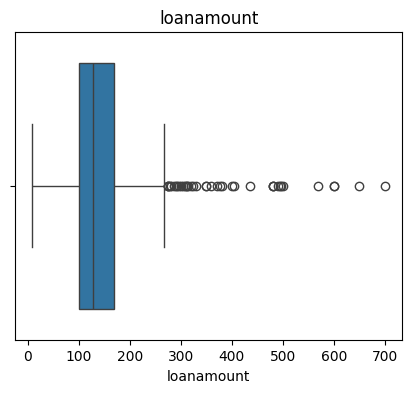

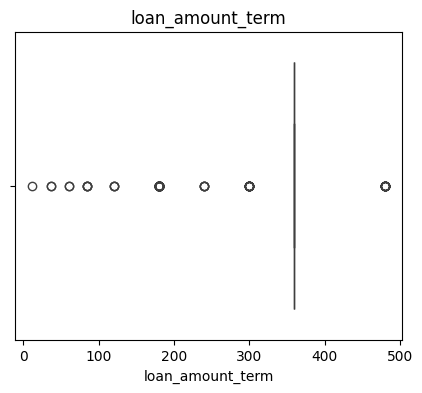

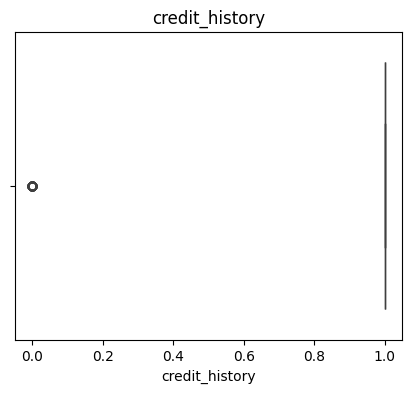

In [74]:
for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x = df[col])
    plt.title(col)
    plt.show()

In [75]:
outliers_col = ["applicantincome","coapplicantincome","loanamount"]

In [76]:
outliers_col

['applicantincome', 'coapplicantincome', 'loanamount']

In [77]:
X_train_out.isna().sum()

gender               0
married              0
dependents           0
education            0
self_employed        0
applicantincome      0
coapplicantincome    0
loanamount           0
loan_amount_term     0
credit_history       0
property_area        0
dtype: int64

In [78]:
def get_bounds(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1
    lowerbound = max(0,Q1-1.5*IQR)
    upperbound = Q3+1.5*IQR
    return lowerbound,upperbound
    

In [79]:
def compute_train_bound(X_train_out,num_col):
    bound = {}
    for col in num_col:
        lower,high = get_bounds(X_train_out[col])
        bound[col] = (lower,high)
    return bound

In [80]:
def capped_train_bound(X_train_out,bounds):
    for col,(lower,high) in bounds.items():
        # lower bound
        X_train_out[col] = np.where(X_train_out[col] <lower,lower,X_train_out[col])

        # upper bound
        X_train_out[col] = np.where(X_train_out[col] > high,high,X_train_out[col])

    return X_train_out
                                

In [81]:
train_bounds = compute_train_bound(X_train_out,outliers_col)

In [82]:
X_train_cap = capped_train_bound(X_train_out,train_bounds)
X_test_cap = capped_train_bound(X_test_out,train_bounds)

In [83]:
print("Shape of X_train:",X_train_cap.shape)
print("Shape of X_test:",X_test_cap.shape)

Shape of X_train: (491, 11)
Shape of X_test: (123, 11)


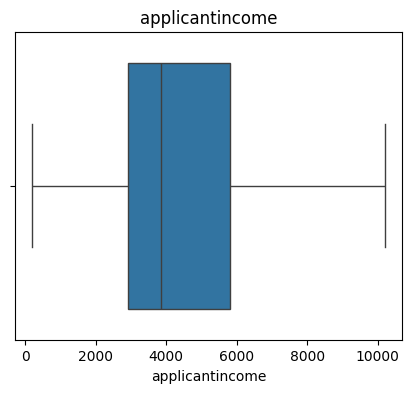

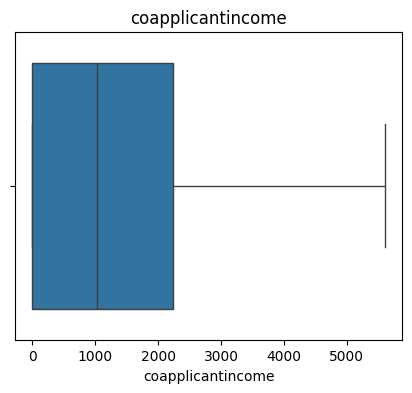

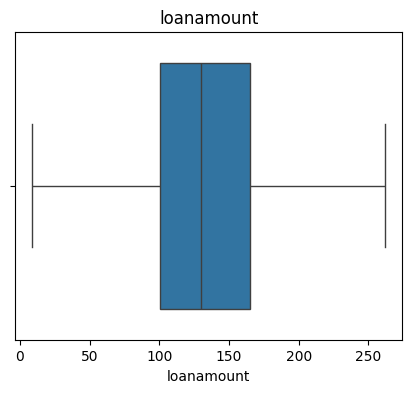

In [84]:
for col in outliers_col:
    plt.figure(figsize=(5,4))
    sns.boxplot(x = X_train_cap[col])
    plt.title(col)
    plt.show()

**4.5 Convert the categorical data into numerical**

by the help of Onehot Encoding because it has no order

In [85]:
print("Shape of X_train:",X_train_cap.shape)
print("Shape of X_test:",X_test_cap.shape)

Shape of X_train: (491, 11)
Shape of X_test: (123, 11)


In [86]:
cat_cols

['property_area']

In [87]:
one_hot_handle = ["property_area"]

In [88]:
X_train_cap.columns

Index(['gender', 'married', 'dependents', 'education', 'self_employed',
       'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area'],
      dtype='str')

In [89]:
ohe = OneHotEncoder(drop="first",handle_unknown ="ignore",sparse_output = False)

In [90]:
ohe.fit(X_train_cap[one_hot_handle])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_c

In [91]:
train_ohe = ohe.transform(X_train_cap[one_hot_handle])
test_ohe = ohe.transform(X_test_cap[one_hot_handle])

In [92]:
train_ohe

array([[0., 1.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [1., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [1., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 0.],
       [0., 0.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.

In [93]:
ohe_col = ohe.get_feature_names_out(one_hot_handle)

In [94]:
ohe_col

array(['property_area_Semiurban', 'property_area_Urban'], dtype=object)

In [95]:
train_ohe = pd.DataFrame(train_ohe,columns = ohe_col,index = X_train_cap.index)
test_ohe = pd.DataFrame(test_ohe,columns = ohe_col,index = X_test_cap.index)

In [96]:
train_ohe

,property_area_Semiurban,property_area_Urban
154,0.0,1.0
239,1.0,0.0
448,0.0,0.0
471,0.0,0.0
273,1.0,0.0
...,...,...
222,1.0,0.0
349,0.0,0.0
26,1.0,0.0
96,1.0,0.0


In [97]:
test_ohe

,property_area_Semiurban,property_area_Urban
150,0.0,0.0
559,1.0,0.0
598,0.0,0.0
235,0.0,0.0
145,1.0,0.0
...,...,...
363,0.0,1.0
280,0.0,1.0
7,1.0,0.0
289,0.0,0.0


In [98]:
# here we remove the original columns and concatenate the new data

In [99]:
X_train_cap = X_train_cap.drop(columns = ["property_area"])
X_test_cap = X_test_cap.drop(columns = ["property_area"])

In [100]:
X_test_cap.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history
150,1.0,0.0,0.0,0,0.0,6277.0,0.0,118.0,360.0,0.0
559,0.0,1.0,0.0,0,0.0,4180.0,2306.0,182.0,360.0,1.0
598,1.0,1.0,0.0,0,1.0,9963.0,0.0,180.0,360.0,1.0
235,1.0,1.0,1.0,0,0.0,5500.0,1260.0,170.0,360.0,1.0
145,0.0,1.0,0.0,0,0.0,2330.0,4486.0,100.0,360.0,1.0


In [101]:
# now concatenate the train_ohe and test_ohe with the help of pandas dataframe

In [102]:
X_train_enc = pd.concat([X_train_cap,train_ohe],axis = 1)
X_test_enc = pd.concat([X_test_cap,test_ohe],axis = 1)

In [103]:
X_train_enc

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area_Semiurban,property_area_Urban
154,1.0,0.0,0.0,0,0.0,3254.0,0.0,50.0,360.0,1.0,0.0,1.0
239,1.0,1.0,1.0,0,0.0,3315.0,0.0,96.0,360.0,1.0,1.0,0.0
448,1.0,1.0,2.0,0,0.0,3340.0,1710.0,150.0,360.0,0.0,0.0,0.0
471,1.0,1.0,1.0,1,0.0,2653.0,1500.0,113.0,180.0,0.0,0.0,0.0
273,1.0,1.0,0.0,0,0.0,2620.0,2223.0,150.0,360.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
222,1.0,0.0,0.0,0,0.0,2971.0,2791.0,144.0,360.0,1.0,1.0,0.0
349,1.0,1.0,0.0,0,0.0,2625.0,5602.5,187.0,360.0,1.0,0.0,0.0
26,1.0,1.0,0.0,0,0.0,2799.0,2253.0,122.0,360.0,1.0,1.0,0.0
96,0.0,1.0,0.0,0,0.0,2484.0,2302.0,137.0,360.0,1.0,1.0,0.0


In [104]:
X_test_enc

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area_Semiurban,property_area_Urban
150,1.0,0.0,0.0,0,0.0,6277.0,0.0,118.0,360.0,0.000000,0.0,0.0
559,0.0,1.0,0.0,0,0.0,4180.0,2306.0,182.0,360.0,1.000000,1.0,0.0
598,1.0,1.0,0.0,0,1.0,9963.0,0.0,180.0,360.0,1.000000,0.0,0.0
235,1.0,1.0,1.0,0,0.0,5500.0,1260.0,170.0,360.0,1.000000,0.0,0.0
145,0.0,1.0,0.0,0,0.0,2330.0,4486.0,100.0,360.0,1.000000,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
363,1.0,1.0,0.0,0,0.0,3013.0,3033.0,95.0,300.0,0.850446,0.0,1.0
280,1.0,0.0,1.0,1,1.0,4053.0,2426.0,158.0,360.0,0.000000,0.0,1.0
7,1.0,1.0,3.0,0,0.0,3036.0,2504.0,158.0,360.0,0.000000,1.0,0.0
289,1.0,0.0,0.0,0,0.0,9508.0,0.0,187.0,360.0,1.000000,0.0,0.0


In [105]:
print("Shape of X_train_enc:",X_train_enc.shape)
print("Shape of X_test_enc:",X_test_enc.shape)

Shape of X_train_enc: (491, 12)
Shape of X_test_enc: (123, 12)


**4.5 Handle The Imbalance data**

In [106]:
y_train.value_counts()

loan_status
1    337
0    154
Name: count, dtype: int64

In [107]:
y_train.value_counts(normalize = True)

loan_status
1    0.686354
0    0.313646
Name: proportion, dtype: float64

In [108]:
# We handle the data imbalance by using the Smote function

In [109]:
#smote = SMOTE(random_state = 42)

In [110]:
#X_train_smote,y_train_smote = smote.fit_resample(X_train_enc,y_train)

In [111]:
#y_train_smote.value_counts(normalize = True)

In [112]:
#print("Shape of X_train_enc:",X_train_enc.shape)
#print("Shape of X_test_enc:",X_test_enc.shape)
#print("Shape of X_train_smote :",X_train_smote.shape)
#print("Shape of X_test_smote :",X_test_enc.shape)

**4.6 Scaling using the Standard Scaler**

In [113]:
print("Shape of X_train_enc:",X_train_enc.shape)
print("Shape of X_test_enc:",X_test_enc.shape)
#print("Shape of X_train_smote :",X_train_smote.shape)
print("Shape of X_test_smote :",X_test_enc.shape)

Shape of X_train_enc: (491, 12)
Shape of X_test_enc: (123, 12)
Shape of X_test_smote : (123, 12)


In [114]:
df.shape

(614, 12)

In [115]:
scaler = StandardScaler()

In [116]:
X_train_scale = scaler.fit_transform(X_train_enc)
X_test_scale = scaler.transform(X_test_enc)

In [117]:
X_train_scale_df = pd.DataFrame(X_train_scale,columns = X_train_enc.columns,index=X_train_enc.index)
X_test_scale_df = pd.DataFrame(X_test_scale,columns=X_train_enc.columns,index=X_test_enc.index)

In [118]:
X_train_scale_df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,491.0,-2.496306e-16,1.00102,-2.149596,0.475865,0.475865,0.475865,0.475865
married,491.0,3.256051e-17,1.00102,-1.378107,-1.378107,0.730094,0.730094,0.730094
dependents,491.0,4.341402e-17,1.00102,-0.764542,-0.764542,-0.764542,0.238919,2.245841
education,491.0,-1.808917e-17,1.00102,-0.540468,-0.540468,-0.540468,-0.540468,1.850250
self_employed,491.0,5.245860e-17,1.00102,-0.418902,-0.418902,-0.418902,-0.418902,2.526105
applicantincome,491.0,1.230064e-16,1.00102,-1.807171,-0.713846,-0.327371,0.469913,2.245551
coapplicantincome,491.0,3.617835e-17,1.00102,-0.856225,-0.856225,-0.218934,0.527660,2.603487
loanamount,491.0,2.930446e-16,1.00102,-2.306808,-0.680009,-0.155521,0.466752,2.186893
loan_amount_term,491.0,-1.899363e-16,1.00102,-5.067702,0.288008,0.288008,0.288008,2.134804
credit_history,491.0,-7.597453e-17,1.00102,-2.496473,0.439012,0.439012,0.439012,0.439012


In [119]:
X_test_scale_df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,123.0,-0.065503,1.058650,-2.149596,0.475865,0.475865,0.475865,0.475865
married,123.0,-0.024059,1.014657,-1.378107,-1.378107,0.730094,0.730094,0.730094
dependents,123.0,0.005050,1.030709,-0.764542,-0.764542,-0.764542,0.238919,2.245841
education,123.0,-0.093423,0.935965,-0.540468,-0.540468,-0.540468,-0.540468,1.850250
self_employed,123.0,-0.018783,0.991582,-0.418902,-0.418902,-0.418902,-0.418902,2.526105
applicantincome,123.0,-0.094168,1.036431,-1.831503,-0.818069,-0.424294,0.341966,2.245551
coapplicantincome,123.0,0.088343,0.976071,-0.856225,-0.856225,0.059572,0.674632,2.603487
loanamount,123.0,-0.059742,0.959536,-2.022341,-0.671119,-0.262197,0.431193,2.186893
loan_amount_term,123.0,0.053601,0.951095,-3.959624,0.288008,0.288008,0.288008,2.134804
credit_history,123.0,-0.111018,1.122472,-2.496473,0.439012,0.439012,0.439012,0.439012


-- I do correct Scaling the data.

-- I do Preprocessing correctly now i will move on next Point which is Baseline model

### **5.BaseLine Model**

In [120]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

In [121]:
# Train accuracy
model.fit(X_train_scale_df,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [122]:
model.score(X_train_scale_df,y_train)

1.0

In [123]:
model.score(X_test_scale_df,y_test)

0.8455284552845529

In [124]:
y_pred = model.predict(X_test_scale_df)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.66      0.72        38
           1       0.86      0.93      0.89        85

    accuracy                           0.85       123
   macro avg       0.83      0.79      0.81       123
weighted avg       0.84      0.85      0.84       123



In [129]:
# Training  average precision score

y_train_prob = model.predict_proba(X_train_scale_df)[:,1]
print("Training Average precision sccore :",average_precision_score(y_train,y_train_prob))

Training Average precision sccore : 1.0


In [132]:
y_test_proba = model.predict_proba(X_test_scale_df)[:,1]
print("Test Average Precision score :",average_precision_score(y_test,y_test_proba))

Test Average Precision score : 0.8461676678990848


### **6.Model Selection**

In [134]:
k = 5
cv = StratifiedKFold(n_splits = k,shuffle = True,random_state = 42)

In [143]:
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "HistGB": HistGradientBoostingClassifier(random_state=42),
    "SVC": SVC(probability=True, class_weight="balanced")
}

In [168]:
results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train_scale_df,
        y_train,
        cv=cv,
        scoring={
            "f1_macro": "f1_macro",
            "pr_auc": "average_precision"
        }
    )

    print(name)
    print("F1 Macro:", scores["test_f1_macro"].mean())
    print("PR AUC:", scores["test_pr_auc"].mean())
    print("-"*50)

    results[name] = {
        "f1_macro": scores["test_f1_macro"].mean(),
        "pr_auc": scores["test_pr_auc"].mean()
    }

DecisionTree
F1 Macro: 0.6258956104222031
PR AUC: 0.7498027372436576
--------------------------------------------------
RandomForest
F1 Macro: 0.6970653588492903
PR AUC: 0.861171083657403
--------------------------------------------------
ExtraTrees
F1 Macro: 0.7118322390883142
PR AUC: 0.8411238563933751
--------------------------------------------------
AdaBoost
F1 Macro: 0.7066415648350421
PR AUC: 0.8562241184082471
--------------------------------------------------
HistGB
F1 Macro: 0.7013590953612826
PR AUC: 0.8400837796300167
--------------------------------------------------
SVC
F1 Macro: 0.6764301815140635
PR AUC: 0.851125467713096
--------------------------------------------------


**Best Model as per model selection process:** RandomForestClassifier

### **7.HyperParameter Tuning for RandomForest Classifier**

In [170]:
rfc_pipeline = Pipeline(
    [
        ("model",RandomForestClassifier(random_state = 42,class_weight = "balanced",n_jobs = -1))
    ]
)

In [172]:
# hyperparameter tuning for randomForest Classifier
param_dist = {
    "model__n_estimators" :[200,300,500],
    "model__max_depth" : [None,10,20,30],
    "model__min_samples_leaf" : [1,5,10,20],
    "model__max_features" : ["sqrt","log2",0.5]
}

In [176]:
# random search CV
random_search = RandomizedSearchCV(
    estimator = rfc_pipeline,
    param_distributions = param_dist,
    n_iter = 10,
    random_state = 42,
    scoring = "average_precision",
    cv = cv,
    verbose = True
)

In [177]:
random_search.fit(X_train_scale_df,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [200, 300, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [179]:
print("Best CV PR-AUC :",random_search.best_score_)
print("Best Params :",random_search.best_params_)

Best CV PR-AUC : 0.8734462557059205
Best Params : {'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 20}


### **8.Retrain with best parameter**

In [184]:
best_rfc = Pipeline(
    [
        (
        "model",RandomForestClassifier( 
        n_estimators = 300,
        min_samples_leaf = 1,
        max_features = 0.5,
        max_depth = 20,
        random_state = 42,
        n_jobs = -1,
        class_weight = "balanced_subsample"
        ) 
        )
    ]
)

In [185]:
best_rfc.fit(X_train_scale_df,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If fl

### **9.Model Evaluation**

In [187]:
# training data predictions.
y_pred_train = best_rfc.predict(X_train_scale_df)

In [188]:
test_accuracy = accuracy_score(y_train,y_pred_train)
print(test_accuracy)

1.0


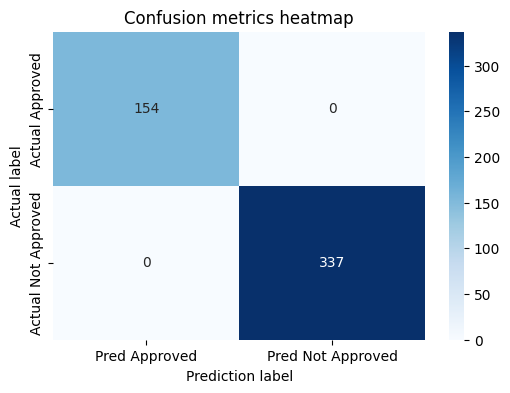

In [199]:
# Confusion metrics

cm = confusion_matrix(y_train,y_pred_train)
plt.figure(figsize = (6,4))
# heatmap
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = ["Pred Approved","Pred Not Approved"],
    yticklabels = ["Actual Approved","Actual Not Approved"]
    
)
plt.xlabel("Prediction label")
plt.ylabel("Actual label")
plt.title("Confusion metrics heatmap")
plt.show()

In [201]:
print("Training Classificcation report:")
print(classification_report(y_train,y_pred_train))

Training Classificcation report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00       337

    accuracy                           1.00       491
   macro avg       1.00      1.00      1.00       491
weighted avg       1.00      1.00      1.00       491



In [210]:
train_proba = best_rfc.predict_proba(X_train_scale_df)[:,1]
print("Best PR - AUC ",round(average_precision_score(y_train,train_proba),2)*100)

Best PR - AUC  100.0


In [204]:
# test data predictions.
y_pred_test = best_rfc.predict(X_test_scale_df)

In [205]:
test_accuracy = accuracy_score(y_test,y_pred_test)
print(test_accuracy)

0.8292682926829268


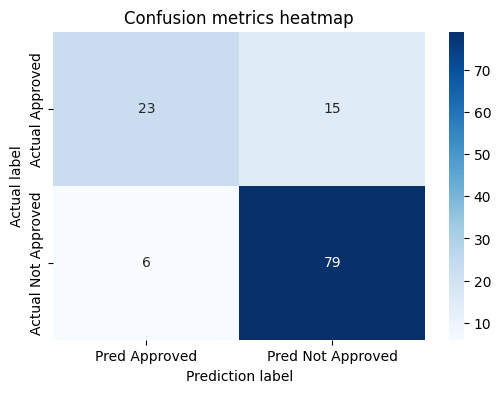

In [206]:
# Confusion metrics

cm = confusion_matrix(y_test,y_pred_test)
plt.figure(figsize = (6,4))
# heatmap
sns.heatmap(
    cm,
    annot = True,
    fmt = "d",
    cmap = "Blues",
    xticklabels = ["Pred Approved","Pred Not Approved"],
    yticklabels = ["Actual Approved","Actual Not Approved"]
    
)
plt.xlabel("Prediction label")
plt.ylabel("Actual label")
plt.title("Confusion metrics heatmap")
plt.show()

In [207]:
print("Test Classificcation report:")
print(classification_report(y_test,y_pred_test))

Test Classificcation report:
              precision    recall  f1-score   support

           0       0.79      0.61      0.69        38
           1       0.84      0.93      0.88        85

    accuracy                           0.83       123
   macro avg       0.82      0.77      0.78       123
weighted avg       0.83      0.83      0.82       123



In [209]:
test_proba = best_rfc.predict_proba(X_test_scale_df)[:,1]
print("Best PR - AUC ",round(average_precision_score(y_test,test_proba),2)*100)

Best PR - AUC  86.0


### **10 Build a predictive System**

In [219]:
def predict_class(input_features):
    input_df = pd.DataFrame([input_features],columns = X_train_scale_df.columns)
    # get prediction from model trained
    prediction = best_rfc.predict(input_df)
    print("Model_prediction :",prediction)
    if prediction[0] == 1:
        print("Loan Approved")
    else:
        print("Loan Rejected")

In [212]:
y_test[y_test == 0].head()

150    0
191    0
569    0
517    0
399    0
Name: loan_status, dtype: int64

In [213]:
y_test[y_test ==1].head()

559    1
598    1
235    1
145    1
557    1
Name: loan_status, dtype: int64

In [214]:
X_test_scale_df.head()

,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area_Semiurban,property_area_Urban
150,0.475865,-1.378107,-0.764542,-0.540468,-0.418902,0.653215,-0.856225,-0.368872,0.288008,-2.496473,-0.774176,-0.701713
559,-2.149596,0.730094,-0.764542,-0.540468,-0.418902,-0.197194,0.567799,0.768999,0.288008,0.439012,1.291696,-0.701713
598,0.475865,0.730094,-0.764542,-0.540468,2.526105,2.148020,-0.856225,0.733440,0.288008,0.439012,-0.774176,-0.701713
235,0.475865,0.730094,0.238919,-0.540468,-0.418902,0.338114,-0.078137,0.555648,0.288008,0.439012,-0.774176,-0.701713
145,-2.149596,0.730094,-0.764542,-0.540468,-0.418902,-0.947435,1.914014,-0.688898,0.288008,0.439012,1.291696,-0.701713


In [227]:
test_1 = X_test_scale_df.loc[399].to_list()
print(test_1)

[-2.1495956583164366, -1.3781066369491788, -0.7645415682118334, -0.5404676337745812, -0.4189017623931998, -1.284029655457801, 0.2553288012584738, -0.635560500483267, 0.28800769852497954, -2.4964727248856695, 1.2916958855975214, -0.7017130580269054]


In [228]:
predict_class(test_1)

Model_prediction : [0]
Loan Rejected


In [236]:
test_2 = X_test_scale_df.loc[569].to_list()
print(test_2)

[0.47586468771890555, 0.7300941117379662, -0.7645415682118334, -0.5404676337745812, -0.4189017623931998, -0.6084069756434823, 0.41835673267527407, -0.617781267219336, 0.28800769852497954, -2.4964727248856695, -0.7741760356675698, 1.42508392648674]


In [237]:
predict_class(test_2)

Model_prediction : [0]
Loan Rejected


In [234]:
test_3 = X_test_scale_df.loc[235].to_list()
print(test_3)

[0.47586468771890555, 0.7300941117379662, 0.238919240066198, -0.5404676337745812, -0.4189017623931998, 0.3381136334121118, -0.07813742209407229, 0.5556481282001053, 0.28800769852497954, 0.4390122639562725, -0.7741760356675698, -0.7017130580269054]


In [235]:
predict_class(test_3)

Model_prediction : [1]
Loan Approved
